Per-block exact matches:
  global_view_0                  :        1 /      306  ( 0.33%)
  global_view_1                  :        0 /       17  ( 0.00%)
  global_view_2                  :        4 /     1734  ( 0.23%)
  global_view_3                  :        0 /       34  ( 0.00%)
  global_view_4                  :      123 /     6936  ( 1.77%)
  global_view_5                  :        0 /       68  ( 0.00%)
  global_view_double_period_0    :        0 /      144  ( 0.00%)
  global_view_double_period_1    :        0 /       16  ( 0.00%)
  global_view_double_period_2    :        2 /     1536  ( 0.13%)
  global_view_double_period_3    :        0 /       32  ( 0.00%)
  global_view_double_period_4    :      132 /     6144  ( 2.15%)
  global_view_double_period_5    :        2 /       64  ( 3.12%)
  local_aperture_s_0             :        2 /      240  ( 0.83%)
  local_aperture_s_1             :        0 /       16  ( 0.00%)
  local_aperture_s_2             :        2 /     1280  ( 0.16%)


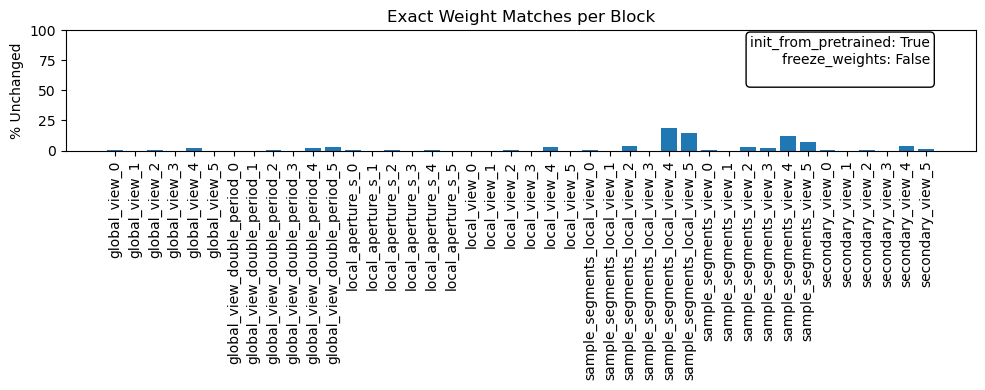

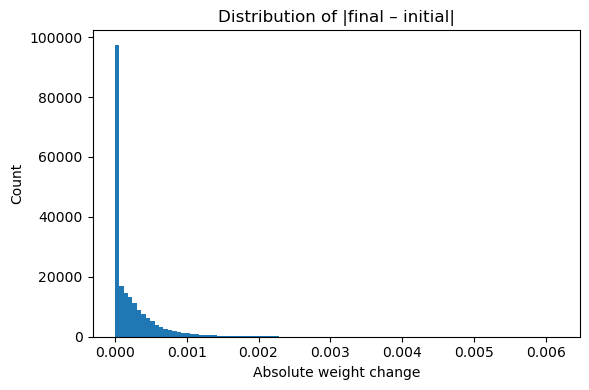

In [42]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import json

time='180647'

# ─── CONFIG ───────────────────────────────────────────────────────────────────────
initial_path = (f"mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time}/initial_block_weights.npz")
final_path = (f"mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time}/final_block_weights.npz")

# ────────────────────────────────────────────────────────────────────────────────


config_path = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time}/config.json")

#"init_from_pretrained_model": true,
#"freeze_pretrained_params": false,
#
# Load the config
with open(config_path, "r") as f:
    config = json.load(f)
    init_from_pretrained = config.get("init_from_pretrained_model", None)
    freeze_weights = config.get("freeze_pretrained_params", None)


# Load both archives
init = np.load(initial_path)
fin  = np.load(final_path)

# Find the intersection of keys (blocks) present in both
blocks = sorted(set(init.files) & set(fin.files))

# … after loading init[...] and fin[...] …
matches_per_block = {}
total_per_block   = {}

# tolerances
rtol = 1e-5
atol = 1e-8

for blk in blocks:
    w0 = init[blk]
    w1 = fin[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block[blk] = matches
    total_per_block[blk]   = total


# Print per-block counts
print("Per-block exact matches:")
for blk in blocks:
    m = matches_per_block[blk]
    t = total_per_block[blk]
    pct = m / t * 100
    print(f"  {blk:30s} : {m:8d} / {t:8d}  ({pct:5.2f}%)")

# Print overall
overall_matches = sum(matches_per_block.values())
overall_total   = sum(total_per_block.values())
print("\nOverall exact matches:")
print(f"  {overall_matches} / {overall_total}  "
      f"({overall_matches/overall_total*100:.2f}%)")

# ─── VISUALIZATION ───────────────────────────────────────────────────────────────

# 1) Bar chart of % unchanged per block
labels = blocks
percent_unchanged = [
    matches_per_block[b] / total_per_block[b] * 100 for b in labels
]

plt.figure(figsize=(10, 4))
plt.bar(labels, percent_unchanged)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("% Unchanged")
plt.title("Exact Weight Matches per Block")

#add a text box with the config values
config_text = (
    f"init_from_pretrained: {init_from_pretrained}\n"
    f"freeze_weights: {freeze_weights}\n"
)
plt.gca().text(
    0.95, 0.95, config_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))






plt.tight_layout()
plt.ylim(0, 100)
plt.show()

# 2) Histogram of absolute weight changes
#    (flatten diffs across all blocks)
all_diffs = np.concatenate([
    (fin[b] - init[b]).ravel() for b in blocks
])

plt.figure(figsize=(6, 4))
plt.hist(np.abs(all_diffs), bins=100)
plt.xlabel("Absolute weight change")
plt.ylabel("Count")
plt.title("Distribution of |final – initial|")
plt.tight_layout()
plt.show()


[False, False]


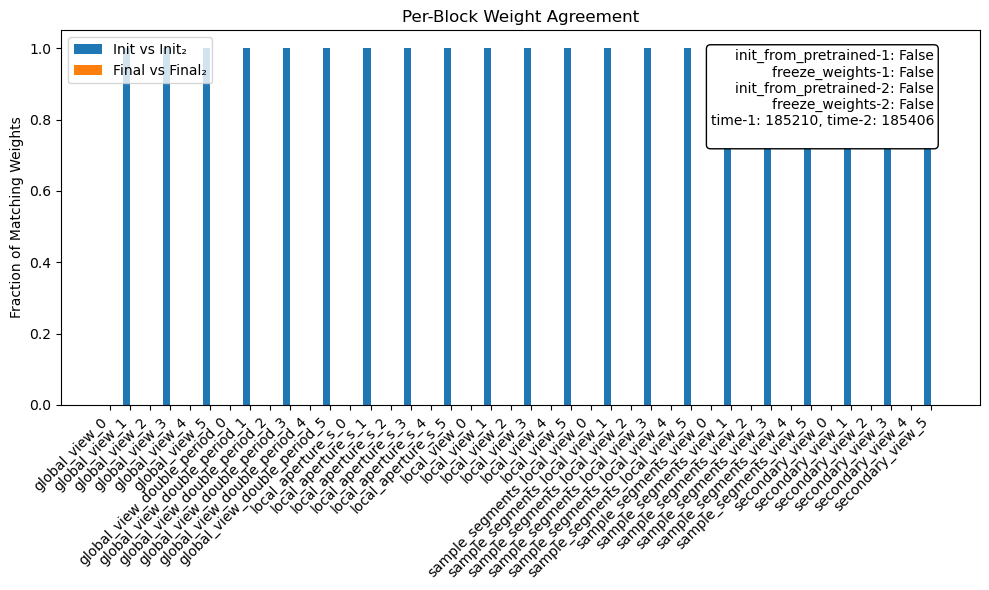

In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import json

TF1='180647'
TF2='184345'
TT='182135'
FF1='185210'
FF2='185406'

time1=FF1
time2=FF2

# ─── CONFIG ───────────────────────────────────────────────────────────────────────
initial_path_1 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time1}/initial_block_weights.npz")
initial_path_2 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time2}/initial_block_weights.npz")

final_path_1 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time1}/final_block_weights.npz")
final_path_2 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time2}/final_block_weights.npz")
# ────────────────────────────────────────────────────────────────────────────────


config_path_1 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time1}/config.json")
config_path_2 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time2}/config.json")

init_from_pretrained = [None, None]
freeze_weights = [None, None]
# Load the config
for i,config_path in enumerate([config_path_1, config_path_2]):
    with open(config_path, "r") as f:
        config = json.load(f)
        init_from_pretrained[i] = config.get("init_from_pretrained_model", None)
        freeze_weights[i] = config.get("freeze_pretrained_params", None)

print(init_from_pretrained)


# Load both archives
init1 = np.load(initial_path_1)
init2 = np.load(initial_path_2)

fin1  = np.load(final_path_1)
fin2  = np.load(final_path_2)

# Find the intersection of keys (blocks) present in both
blocks = sorted(set(init1.files) & set(fin1.files))

# … after loading init[...] and fin[...] …
matches_per_block_init = {}
total_per_block_init   = {}
matches_per_block_final = {}
total_per_block_final   = {}

# tolerances
rtol = 1e-5
atol = 1e-8

for blk in blocks:
    w0 = init1[blk]
    w1 = init2[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block_init[blk] = matches
    total_per_block_init[blk]   = total

    w0 = fin1[blk]
    w1 = fin2[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block_final[blk] = matches
    total_per_block_final[blk]   = total



# 1) compute fractions
frac_init  = [matches_per_block_init[blk]  / total_per_block_init[blk]  for blk in blocks]
frac_final = [matches_per_block_final[blk] / total_per_block_final[blk] for blk in blocks]

# 2) plot
x     = np.arange(len(blocks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, frac_init,  width, label='Init vs Init₂')
ax.bar(x + width/2, frac_final, width, label='Final vs Final₂')

# labels & legend
ax.set_xticks(x)
ax.set_xticklabels(blocks, rotation=45, ha='right')
ax.set_ylabel('Fraction of Matching Weights')
ax.set_title('Per-Block Weight Agreement')
ax.legend()

# Text box with config values
config_text = (
    f"init_from_pretrained-1: {init_from_pretrained[0]}\n"
    f"freeze_weights-1: {freeze_weights[0]}\n"
    f"init_from_pretrained-2: {init_from_pretrained[1]}\n"
    f"freeze_weights-2: {freeze_weights[1]}\n"
    f"time-1: {time1}, time-2: {time2}\n"
)
ax.text(
    0.95, 0.95, config_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))

plt.tight_layout()
plt.show()
